# 03 — Random Forest Model
Train and evaluate a Random Forest classifier.

In [1]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
df = pd.read_csv('../data/processed_dataset.csv')
X = df.drop('Health_Status', axis=1)
y = df['Health_Status']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
rf = RandomForestClassifier(n_estimators=100, max_depth=None, random_state=42)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print('Random Forest Accuracy:', acc)
print(classification_report(y_test, y_pred))

Random Forest Accuracy: 0.9875
              precision    recall  f1-score   support

           0       1.00      0.98      0.99        60
           1       0.98      0.99      0.98        80
           2       0.99      0.99      0.99       100

    accuracy                           0.99       240
   macro avg       0.99      0.99      0.99       240
weighted avg       0.99      0.99      0.99       240



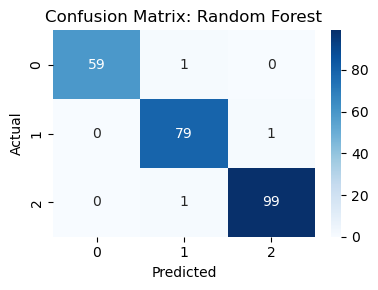

In [2]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(4,3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix: Random Forest')
plt.tight_layout()
plt.savefig('../../outputs/plots/confusion_matrix_rf.png')
plt.show()

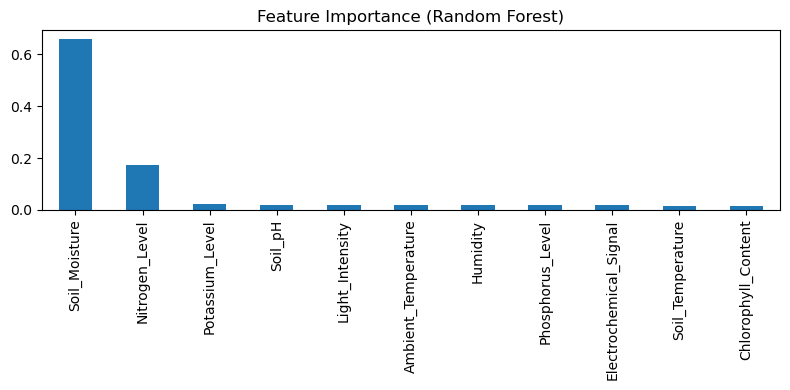

In [3]:
# Feature importance
importances = rf.feature_importances_
feat_imp = pd.Series(importances, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(8,4))
feat_imp.plot(kind='bar')
plt.title('Feature Importance (Random Forest)')
plt.tight_layout()
plt.savefig('../../outputs/plots/feature_importance.png')
plt.show()

In [4]:
# Save model
import os
os.makedirs('../../models', exist_ok=True)
joblib.dump(rf, '../../models/random_forest_model.pkl')
print('Random Forest model saved.')

Random Forest model saved.
